In [ ]:
!pip install xlstm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 36.6 MB/s eta 0:00:00


In [ ]:
from omegaconf import OmegaConf
from pprint import pprint
from dacite import from_dict
from dacite import Config as DaciteConfig
import torch
from xlstm.xlstm_block_stack import xLSTMBlockStack, xLSTMBlockStackConfig


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd drive/MyDrive/ex_comparison_forecasting

Mounted at /content/drive
/content/drive/MyDrive/ex_comparison_forecasting


In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.stats import norm
import math
import sklearn.preprocessing
import pickle
from scipy import interpolate
import random
import time
# import optuna
from sklearn.metrics import mean_absolute_error
from sklearn.multioutput import MultiOutputRegressor
from scipy.stats import linregress
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import r2_score as R2

import argparse
import torch
import torch.nn as nn
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F
import pandas as pd
import torch
import torch.nn as nn
from torch.nn.utils import weight_norm


In [ ]:
# !pip install openseespy

In [ ]:
file_name = 'new_p_data_PINN_3Dex3.p'

### Run OpenSeesPy

In [ ]:
# !pip install openseespy
# import openseespy.opensees as ops

### DL model

In [ ]:
with open(file_name, 'rb') as f:
  df_new = pickle.load(f)

for i in range(len(df_new)):
  L = len(df_new['disp_2'][i])

len(df_new)

1000

In [ ]:
def getPositionEncoding(seq_len, d, n=10000):
    P = np.zeros((seq_len, d))
    for k in range(seq_len):
        for i in np.arange(int(d/2)):
            denominator = np.power(n, 2*i/d)
            P[k, 2*i] = np.sin(k/denominator)
            P[k, 2*i+1] = np.cos(k/denominator)
    return P


In [ ]:
list_output_time = []
list_static = []

for k in list(df_new):
  if (str(k)[:4] == 'disp') & (str(k)[-1] != 'd'):
    list_output_time.append(k)

  if str(k)[:4] != 'disp':
    list_static.append(k)

print(list_static)
print(list_output_time)


['m1', 'm2', 'm3', 'm4', 'm5', 'm6', 'J1', 'J2', 'J3', 'J4', 'J5', 'J6', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'kx1', 'kx2', 'kx3', 'kx4', 'kx5', 'kx6', 'ky1', 'ky2', 'ky3', 'ky4', 'ky5', 'ky6', 'k_theta1', 'k_theta2', 'k_theta3', 'k_theta4', 'k_theta5', 'k_theta6', 'ex1', 'ex2', 'ex3', 'ex4', 'ex5', 'ex6', 'ey1', 'ey2', 'ey3', 'ey4', 'ey5', 'ey6', 'intensity_x', 'intensity_y', 'idEQ']
['disp_1', 'disp_7', 'disp_13', 'disp_19', 'disp_25', 'disp_31', 'disp_2', 'disp_8', 'disp_14', 'disp_20', 'disp_26', 'disp_32', 'disp_3', 'disp_9', 'disp_15', 'disp_21', 'disp_27', 'disp_33', 'disp_4', 'disp_10', 'disp_16', 'disp_22', 'disp_28', 'disp_34', 'disp_5', 'disp_11', 'disp_17', 'disp_23', 'disp_29', 'disp_35', 'disp_6', 'disp_12', 'disp_18', 'disp_24', 'disp_30', 'disp_36']


In [ ]:
L_signal_input = len(df_new['disp_2'][0])
L_ground = L_signal_input

Ndim_encoding = 2
P_encoding = getPositionEncoding(seq_len=L_signal_input, d=Ndim_encoding, n=10000)
list_input_time = ['disp_ground', 'encode_0', 'encode_1']


print(list_input_time)
print(list_output_time)

['disp_ground', 'encode_0', 'encode_1']
['disp_1', 'disp_7', 'disp_13', 'disp_19', 'disp_25', 'disp_31', 'disp_2', 'disp_8', 'disp_14', 'disp_20', 'disp_26', 'disp_32', 'disp_3', 'disp_9', 'disp_15', 'disp_21', 'disp_27', 'disp_33', 'disp_4', 'disp_10', 'disp_16', 'disp_22', 'disp_28', 'disp_34', 'disp_5', 'disp_11', 'disp_17', 'disp_23', 'disp_29', 'disp_35', 'disp_6', 'disp_12', 'disp_18', 'disp_24', 'disp_30', 'disp_36']


In [ ]:
for d in range(Ndim_encoding):
  df_new[f'encode_{d}'] = [P_encoding[:,d]]*len(df_new)


In [ ]:
L_all, L_out = 150, 100
sliding_step = L_out
list_time_series = list_input_time + list_output_time
L_in = L_all-L_out
N_input= len(list_input_time)
N_output= len(list_output_time)
N_static = len(list_static)
N_all = N_input+N_output+N_static
N_time_series = len(list_input_time)+len(list_output_time)+1

max_disp = [np.max(np.abs(df_new[list_output_time[-1]][idx])) for idx in range(len(df_new))]
df_new['max_disp'] = max_disp


In [ ]:
static_scaler = sklearn.preprocessing.StandardScaler().fit(df_new[list_static].values)
target = np.array([df_new[i][0] for i in list_output_time]).T
target_scaler = sklearn.preprocessing.StandardScaler().fit(target)
real = np.array([df_new[i][0] for i in list_time_series]).T
real_scaler = sklearn.preprocessing.StandardScaler().fit(real)

In [ ]:
def prepare_data_batch(x, N1, N2, j = 2):
  N0 = np.shape(x)[1]
  xxx = np.stack([x[:,i:N0 - N1+i+1:j, :] for i in range(N1)], axis=2)
  y = xxx[:,:,-N2:,-len(list_output_time):]

  return np.array(xxx), np.array(y)

In [ ]:
gc.collect(2)
gc.collect(2)

0

In [ ]:
class h_Dataset(Dataset):
    def __init__(self, data_time, data_static, data_y):
        self.data_time = data_time
        self.data_static = data_static
        self.data_y = data_y

    def __getitem__(self, index):
        seq_time = self.data_time[index]
        seq_static = self.data_static[index]
        seq_y = self.data_y[index]
        return seq_time, seq_static, seq_y

    def __len__(self):
        return len(self.data_y)


def data_provider2(data_x, data_y, batch_size=128):
    data_set = h_Dataset(data_x, data_y)
    data_loader = DataLoader( data_set, batch_size=batch_size, shuffle=True, drop_last=True)
    return data_set, data_loader



In [ ]:
class Data_aggregation(nn.Module):
    def __init__(self, dropout=0.1):
        super(Data_aggregation, self).__init__()
        self.projection = nn.Sequential(nn.Linear(N_static, L_all), nn.ReLU(), nn.Linear(L_all, L_all))
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, x_time, x_static):
        x = self.projection(x_static)
        x = self.dropout(x)
        x = x.permute(0, 2, 1)
        x = torch.cat([x_time, x], dim=2)

        return x

In [ ]:

# [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
def gen_data_AI_batch_2_model(df_new, list_idx):
  signal = [np.stack(list(df_new[k][list_idx])) for k in list_time_series ]
  signal = np.stack(signal).transpose(1,2,0)
  signal = np.pad(signal,((0,0),(L_all,0),(0,0)),constant_values=0.0)
  signal = signal.reshape(-1, N_input + N_output)
  scaled_signal = real_scaler.transform(signal)
  scaled_signal = scaled_signal.reshape(-1, L_ground+L_all, N_input + N_output)
  X_times_series, Y_label = prepare_data_batch(scaled_signal, L_all, L_out, j = sliding_step)
  X_times_series[:,:,L_in:,N_input:N_input+N_output] = 0.0

  static = np.stack(list(df_new[k][list_idx] for k in list_static)).T
  scaled_static = static_scaler.transform(static)
  X_static = scaled_static.reshape(-1,1,1,N_static)
  X_static = np.tile(X_static, [1, X_times_series.shape[1], 1, 1])
  X_times_series = X_times_series.reshape(-1, L_all, N_input+N_output)
  X_static = X_static.reshape(-1, 1, N_static)
  Y_label =  Y_label.reshape(-1, L_out, N_output)

  return X_times_series, X_static, Y_label



In [ ]:
def data_provider2(data_time, data_static, data_y, batch_size=128):
    data_set = h_Dataset(data_time, data_static, data_y)
    data_loader = DataLoader(data_set, batch_size=batch_size, shuffle=True, drop_last=True)
    return data_set, data_loader

def loader_data(df_new, idx_train, batch_size = 128):
  list_train_time, list_train_static, list_train_label = [], [], []
  list_val_time, list_val_static, list_val_label = [], [], []
  time, static, label = gen_data_AI_batch_2_model(df_new, idx_train)
  list_train_time.append(time)
  list_train_static.append(static)
  list_train_label.append(label)

  train_time = np.concatenate(list_train_time, axis=0)
  train_static = np.concatenate(list_train_static, axis=0)
  train_label = np.concatenate(list_train_label, axis=0)
  _, train_loader = data_provider2(train_time, train_static, train_label, batch_size=batch_size)

  return train_loader


In [ ]:
idx_train = np.random.choice(len(df_new), size=500, replace=False)
idx_val = np.array([i for i in range(len(df_new)) if i not in idx_train])
idx_val = idx_val[:200]

train_loader= loader_data(df_new, idx_train, batch_size = 64)
valid_loader = loader_data(df_new, idx_val, batch_size = 64)

In [ ]:
def inference_5tor(model, aggregation, df_new, list_idx, batch_size = 512):
  x_time, x_static, _ = gen_data_AI_batch_2_model(df_new, list_idx)
  x_time = x_time.reshape(len(list_idx),-1,L_all, N_input+N_output)
  x_static = x_static.reshape(len(list_idx),-1, 1, N_static)
  # initial a long output time-series with zero
  y_predict_all = np.zeros((len(x_time), L_ground+L_all, N_output))
  for j in range(int(L_ground/L_out)+1):
    x_time[:,j,:L_all, N_input:N_input+N_output] = y_predict_all[:,L_out*j:L_all+L_out*j,:]
    xt = torch.from_numpy(x_time[:,j,:,:]).float().to('cuda')
    xs = torch.from_numpy(x_static[:,j,:,:]).float().to('cuda')
    batch_x = aggregation(xt, xs)
    y_pred_all = model(batch_x).to('cuda').cpu().detach().numpy()
    y_predict_all[:,L_in+L_out*j:L_all+L_out*j,:] = y_pred_all[:,:,:]

  y_predict_all = target_scaler.inverse_transform(y_predict_all.reshape(-1, N_output))
  y_predict_all = y_predict_all.reshape(len(x_time), -1, N_output)

  return y_predict_all

In [ ]:
class model_parameters:
  def __init__(self):
    self.d_model = 128
    self.e_layers = 2
    self.dropout = 0.1

args = model_parameters()


In [ ]:
xlstm_cfg = f"""
mlstm_block:
  mlstm:
    conv1d_kernel_size: 3
    qkv_proj_blocksize: 4
    num_heads: 1
slstm_block:
  slstm:
    backend: {'cuda' if torch.cuda.is_available() else 'vanilla'}
    num_heads: 1
    conv1d_kernel_size: 3
    bias_init: powerlaw_blockdependent
  feedforward:
    proj_factor: 1.3
    act_fn: gelu
context_length: {L_all}
num_blocks: 1
embedding_dim: {N_input+N_output+1}
slstm_at: []
"""

cfg = OmegaConf.create(xlstm_cfg)
cfg = from_dict(data_class=xLSTMBlockStackConfig, data=OmegaConf.to_container(cfg), config=DaciteConfig(strict=True))
xlstm_stack = xLSTMBlockStack(cfg)


In [ ]:
class ResBlock(nn.Module):
    def __init__(self, configs):
        super(ResBlock, self).__init__()
        self.temporal = nn.Sequential(nn.Linear(L_all, configs.d_model), nn.ReLU(), nn.Linear(configs.d_model, L_all), nn.Dropout(configs.dropout))
        self.channel = nn.Sequential(nn.Linear(N_input+N_output+1, configs.d_model), nn.ReLU(), nn.Linear(configs.d_model, N_input+N_output+1), nn.Dropout(configs.dropout))

    def forward(self, x):
        # x: [B, L, D]
        x = x + self.temporal(x.transpose(1, 2)).transpose(1, 2)
        x = x + self.channel(x)
        return x


class TSMixer_dis(nn.Module):
    def __init__(self, configs):
        super(TSMixer_dis, self).__init__()
        self.layer = configs.e_layers
        self.model = nn.ModuleList([ResBlock(configs) for _ in range(configs.e_layers)])
        self.Lmodel = xLSTMBlockStack(cfg)
        self.projection = nn.Sequential(nn.Linear(L_all, L_out), nn.ReLU())
        self.out_layer = nn.Linear(N_input+N_output+1, N_output, bias=False)

    def forward(self, x_enc):
        x = x_enc
        for i in range(self.layer):
            x = self.model[i](x)

        x = self.Lmodel(x)
        x = self.projection(x.permute(0, 2, 1)).permute(0, 2, 1)
        x_out = self.out_layer(x)
        return x_out




In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
aggregation = Data_aggregation().float().to(device)
model_tor = TSMixer_dis(args).float().to(device)
model_optim = torch.optim.Adam(list(model_tor.parameters())+list(aggregation.parameters()), lr=0.001)
criterion = nn.L1Loss()
list_train_loss_M = []
list_val_loss_M = []


In [ ]:
with open('PINNex3_xlstm_good.p','rb') as f:
  y_predict_all = pickle.load(f)
  y_ref = pickle.load(f)
  list_train_loss_M = pickle.load(f)
  list_val_loss_M = pickle.load(f)
  model_tor = pickle.load(f)
  aggregation = pickle.load(f)


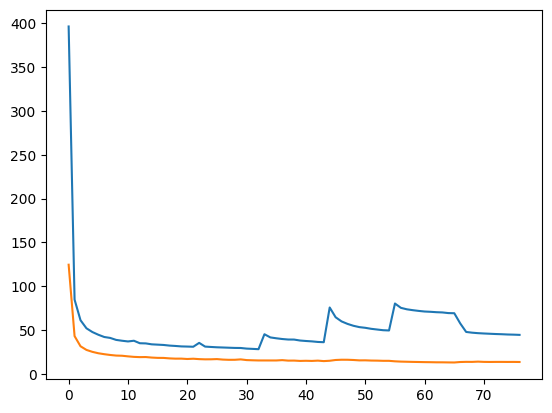

In [ ]:
plt.plot(list_train_loss_M)
plt.plot(list_val_loss_M)

[np.int64(363)]
CPU times: user 137 ms, sys: 72.8 ms, total: 209 ms
Wall time: 746 ms


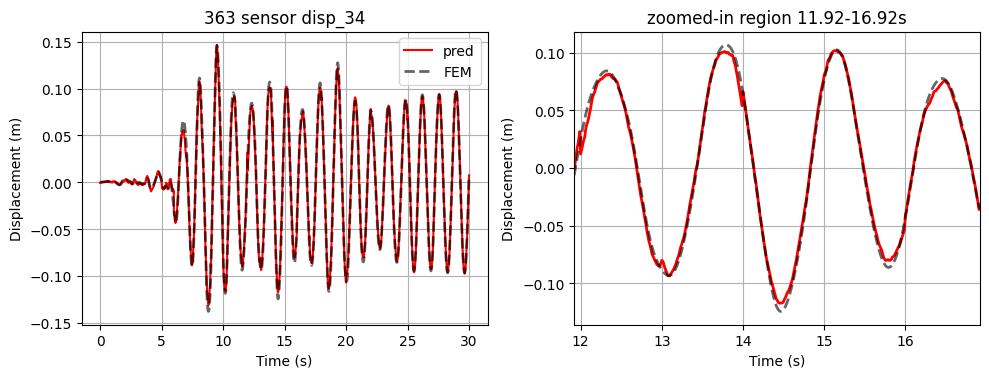

In [ ]:
%%time
plt.figure(figsize=(10,14))

list_ip = [idx_val[np.random.choice(len(idx_val))]]
print(list_ip)
y_predict_all = y_predict_all[list_ip]

list_color = ['r', 'orange', 'm', 'g']
for i,ip in enumerate(list_ip):
  plt.subplot(421+i*2)
  i_s = np.random.randint(N_output)
  # i_s = 0
  length = len(df_new[list_output_time[i_s]][ip])
  t= np.arange(0,len(df_new[list_output_time[i_s]][ip][:]))*0.01
  plt.plot(t, y_predict_all[i, L_all:L_all+L_ground,i_s][:],list_color[i], linewidth=1.5)
  plt.plot(t, df_new[list_output_time[i_s]][ip][:],'--k', alpha = 0.6, linewidth=2)
  plt.legend(['pred', 'FEM'], loc=0)
  plt.title(f'{ip} sensor {list_output_time[i_s]}', fontsize=12)
  plt.xlabel('Time (s)')
  plt.ylabel('Displacement (m)')
  # plt.ylim(-0.04, 0.04)
  # plt.xlim(0,28)
  plt.grid(True)


  plt.subplot(422+i*2)
  length = len(df_new[list_output_time[i_s]][ip])
  t= np.arange(0,len(df_new[list_output_time[i_s]][ip][:]))*0.01
  # t1, t2 = 800, 1200
  t1 = np.random.randint(0,2200)
  t2 = t1+500
  yy = y_predict_all[i, L_all:L_all+length,i_s][:]
  plt.plot(t[t1:t2], yy[t1:t2],list_color[i], linewidth=2)
  yy = df_new[list_output_time[i_s]][ip][:]
  plt.plot(t[t1:t2], yy[t1:t2],'--k', alpha = 0.6, linewidth=2)
  plt.title(f'zoomed-in region {t1/100}-{t2/100}s', fontsize=12)
  plt.xlabel('Time (s)')
  plt.ylabel('Displacement (m)')
  plt.xlim(t1*0.01, t2*0.01)
  plt.grid(True)
  # plt.ylim(-0.042, 0.042)

plt.tight_layout();
# plt.savefig(f'{ex_name}_1.png',dpi=400)
# df['idEQ'][ip]

In [ ]:
%%time
list_ip = list(range(len(df_new)))
y_predict_all = inference_5tor(model_tor, aggregation, df_new, list_ip)


CPU times: user 5.9 s, sys: 5.72 s, total: 11.6 s
Wall time: 12.1 s


In [ ]:
y_ref = df_new[list_output_time].values
y_ref = np.array([np.stack(y_ref[i], axis=1) for i in range(len(y_ref))])

In [ ]:
# with open('PINNex3_xlstm_good.p','wb') as f:
#   pickle.dump(y_predict_all, f)
#   pickle.dump(y_ref, f)
#   pickle.dump(list_train_loss_M, f)
#   pickle.dump(list_val_loss_M, f)
#   pickle.dump(model_tor, f)
#   pickle.dump(aggregation, f)


In [ ]:
ymax_ref = np.max(np.abs(y_ref), axis=(1))
ymax_pred = np.max(np.abs(y_predict_all), axis=(1))

In [ ]:
from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.sans-serif'] = ['Time New Roman']
fsize = 12
rcParams.update({'font.size': fsize})

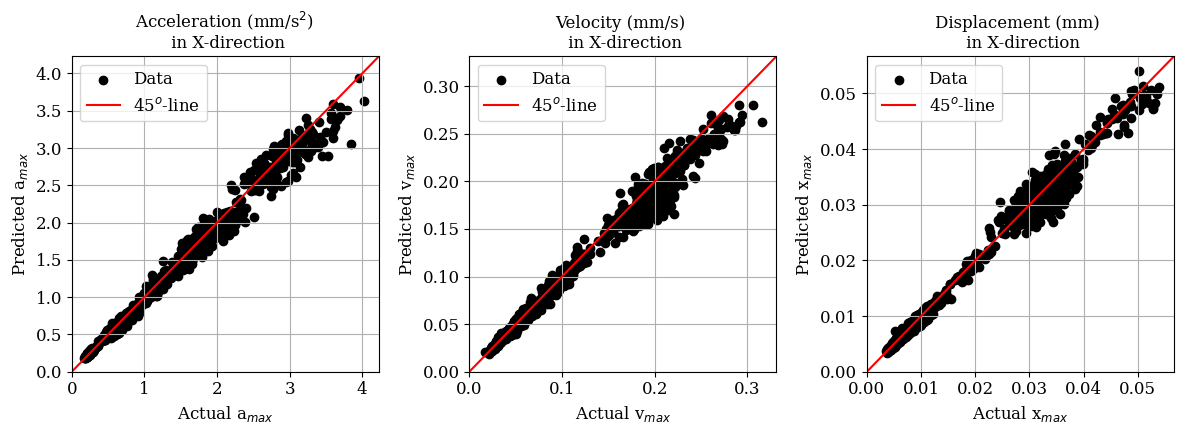

In [ ]:
plt.figure(figsize=(12,4.5))
list_symbol = ['a','v','x']
list_signal = ['Acceleration', 'Velocity', 'Displacement']
list_unit = ['mm/s$^2$','mm/s','mm']

for i in range(3):
  axs = plt.subplot(131+i)
  vmax = np.max(ymax_ref[:,i])*1.05
  plt.scatter(ymax_ref[:,i], ymax_pred[:,i], color='black')
  plt.plot([0,vmax],[0,vmax],'-r')
  plt.ylabel(f'Predicted {list_symbol[i]}'+'$_{max}$')
  plt.xlabel(f'Actual {list_symbol[i]}'+'$_{max}$')
  plt.title(f'{list_signal[i]} ({list_unit[i]}) \n in X-direction', fontsize=12)
  plt.grid(True)
  plt.legend(['Data','45$^o$-line'])
  vlim = vmax
  plt.xlim([0,vlim])
  plt.ylim([0,vlim])
  # plt.yticks([0,np.round(vlim//5, decimals=-1), np.round(vlim*2//5, decimals=-1), np.round(vlim*3//5, decimals=-1), np.round(vlim*4//5, decimals=-1), np.round(vlim)])
  # plt.xticks([0,np.round(vlim//5, decimals=-1), np.round(vlim*2//5, decimals=-1), np.round(vlim*3//5, decimals=-1), np.round(vlim*4//5, decimals=-1), np.round(vlim)])
plt.tight_layout()
# plt.savefig('wall_45.png', dpi=350)



In [ ]:
ymax_ref.shape

(1000, 36)

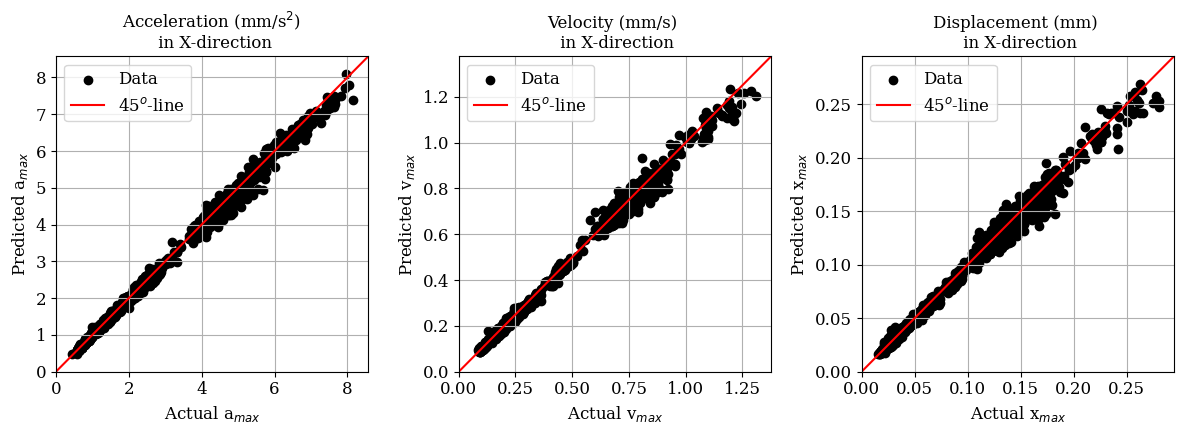

In [ ]:
plt.figure(figsize=(12,4.5))
list_symbol = ['a','v','x']
list_signal = ['Acceleration', 'Velocity', 'Displacement']
list_unit = ['mm/s$^2$','mm/s','mm']

for i in range(3):
  axs = plt.subplot(131+i)
  vmax = np.max(ymax_ref[:,-6+i])*1.05
  plt.scatter(ymax_ref[:,-6+i], ymax_pred[:,-6+i], color='black')
  plt.plot([0,vmax],[0,vmax],'-r')
  plt.ylabel(f'Predicted {list_symbol[i]}'+'$_{max}$')
  plt.xlabel(f'Actual {list_symbol[i]}'+'$_{max}$')
  plt.title(f'{list_signal[i]} ({list_unit[i]}) \n in X-direction', fontsize=12)
  plt.grid(True)
  plt.legend(['Data','45$^o$-line'])
  vlim = vmax
  plt.xlim([0,vlim])
  plt.ylim([0,vlim])
  # plt.yticks([0,np.round(vlim//5, decimals=-1), np.round(vlim*2//5, decimals=-1), np.round(vlim*3//5, decimals=-1), np.round(vlim*4//5, decimals=-1), np.round(vlim)])
  # plt.xticks([0,np.round(vlim//5, decimals=-1), np.round(vlim*2//5, decimals=-1), np.round(vlim*3//5, decimals=-1), np.round(vlim*4//5, decimals=-1), np.round(vlim)])
plt.tight_layout()
# plt.savefig('wall_45.png', dpi=350)



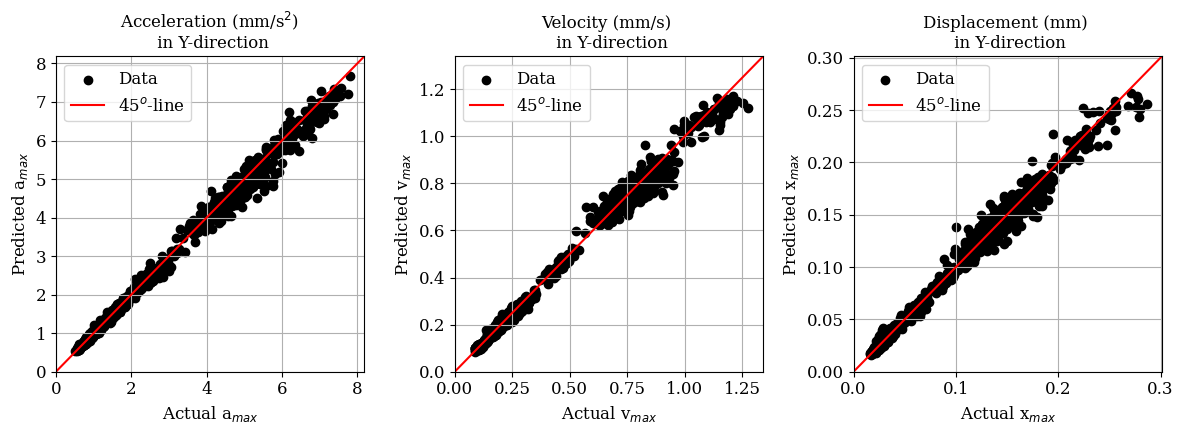

In [ ]:
plt.figure(figsize=(12,4.5))
list_symbol = ['a','v','x']
list_signal = ['Acceleration', 'Velocity', 'Displacement']
list_unit = ['mm/s$^2$','mm/s','mm']

for i in range(3):
  axs = plt.subplot(131+i)
  vmax = np.max(ymax_ref[:,-3+i])*1.05
  plt.scatter(ymax_ref[:,-3+i], ymax_pred[:,-3+i], color='black')
  plt.plot([0,vmax],[0,vmax],'-r')
  plt.ylabel(f'Predicted {list_symbol[i]}'+'$_{max}$')
  plt.xlabel(f'Actual {list_symbol[i]}'+'$_{max}$')
  plt.title(f'{list_signal[i]} ({list_unit[i]}) \n in Y-direction', fontsize=12)
  plt.grid(True)
  plt.legend(['Data','45$^o$-line'])
  vlim = vmax
  plt.xlim([0,vlim])
  plt.ylim([0,vlim])
  # plt.yticks([0,np.round(vlim//5, decimals=-1), np.round(vlim*2//5, decimals=-1), np.round(vlim*3//5, decimals=-1), np.round(vlim*4//5, decimals=-1), np.round(vlim)])
  # plt.xticks([0,np.round(vlim//5, decimals=-1), np.round(vlim*2//5, decimals=-1), np.round(vlim*3//5, decimals=-1), np.round(vlim*4//5, decimals=-1), np.round(vlim)])
plt.tight_layout()
# plt.savefig('wall_45.png', dpi=350)



In [ ]:
from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.sans-serif'] = ['Time New Roman']
fsize = 10
rcParams.update({'font.size': fsize})

In [ ]:
def plot_results2(axs, y_ref, y_predict, fsize=10, ia=0, ii = 100):
  list_signal = ['Acceleration', 'Velocity', 'Displacement']
  list_color = ['r', 'orange', 'm', 'g']
  list_unit = ['mm/s$^2$','mm/s','mm']
  t= np.arange(0,3000)*0.01
  axs[ia, 0].plot(t, y_predict,list_color[ia], linewidth=2)
  axs[ia, 0].plot(t, y_ref,'--k', alpha = 0.6, linewidth=2)
  axs[ia, 0].set_xlim(0,30)
  axs[ia, 0].grid(True)

  t= np.arange(0,3000)*0.01
  ttt = np.argmax(y_ref)
  # ttt = 1100
  t1 = ttt-150
  t2 = t1+300
  axs[ia, 1].plot(t[t1:t2], y_predict[t1:t2],list_color[ia], linewidth=2)
  axs[ia, 1].plot(t[t1:t2], y_ref[t1:t2],'--k', alpha = 0.6, linewidth=2)
  axs[ia, 0].legend(['pred', 'ref'], loc=0)

  # Annotate peak with arrow and error metric using ax.annotate
  peak_time = t[ttt]
  peak_pred = y_ref[ttt]
  abs_error = int(np.abs(y_ref[ttt]  - y_predict[ttt])/y_ref[ttt]*100)
  axs[ia, 1].annotate(
      f'peak error: {abs_error:.1f}%',
      xy=(peak_time, peak_pred),
      xytext=(peak_time-1.5, peak_pred*0.6),
      arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
      bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white'),
      color='red'
  )

  axs[ia, 0].set_title(f'id_{ii} {list_signal[ia]} \n (in X-direction)', fontsize=fsize)
  axs[ia, 1].set_title(f'zoomed-in {t1/100}-{t2/100}s \n (in X-direction)', fontsize=fsize)
  if ia==2:
    axs[ia, 0].set_xlabel('Time (s)')
    axs[ia, 1].set_xlabel('Time (s)')

  axs[ia, 0].set_ylabel(f'{list_signal[ia]} ({list_unit[ia]})')



def plot_results3(axs, y_ref, y_predict, fsize=10, ia=0, ii = 100):
  list_signal = ['Acceleration', 'Velocity', 'Displacement']
  list_color = ['r', 'orange', 'm', 'g']
  list_unit = ['mm/s$^2$','mm/s','mm']
  t= np.arange(0,3000)*0.01
  axs[ia, 2].plot(t, y_predict,list_color[ia], linewidth=2)
  axs[ia, 2].plot(t, y_ref,'--k', alpha = 0.6, linewidth=2)
  axs[ia, 2].set_xlim(0,30)
  axs[ia, 2].grid(True)

  t= np.arange(0,3000)*0.01
  ttt = np.argmax(y_ref)
  # ttt = 1100
  t1 = ttt-150
  t2 = t1+300
  axs[ia, 3].plot(t[t1:t2], y_predict[t1:t2],list_color[ia], linewidth=2)
  axs[ia, 3].plot(t[t1:t2], y_ref[t1:t2],'--k', alpha = 0.6, linewidth=2)
  axs[ia, 2].legend(['pred', 'ref'], loc=0)

  # Annotate peak with arrow and error metric using ax.annotate
  peak_time = t[ttt]
  peak_pred = y_ref[ttt]
  abs_error = int(np.abs(y_ref[ttt]  - y_predict[ttt])/y_ref[ttt]*100)
  axs[ia, 3].annotate(
      f'peak error: {abs_error:.1f}%',
      xy=(peak_time, peak_pred),
      xytext=(peak_time-1.5, peak_pred*0.6),
      arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
      bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white'),
      color='red'
  )

  axs[ia, 2].set_title(f'id_{ii} {list_signal[ia]} \n (in Y-direction)', fontsize=fsize)
  axs[ia, 3].set_title(f'zoomed-in {t1/100}-{t2/100}s \n (in Y-direction)', fontsize=fsize)
  if ia==2:
    axs[ia, 2].set_xlabel('Time (s)')
    axs[ia, 3].set_xlabel('Time (s)')

  axs[ia, 2].set_ylabel(f'{list_signal[ia]} ({list_unit[ia]})')



In [ ]:
list_output_time

['disp_1',
 'disp_7',
 'disp_13',
 'disp_19',
 'disp_25',
 'disp_31',
 'disp_2',
 'disp_8',
 'disp_14',
 'disp_20',
 'disp_26',
 'disp_32',
 'disp_3',
 'disp_9',
 'disp_15',
 'disp_21',
 'disp_27',
 'disp_33',
 'disp_4',
 'disp_10',
 'disp_16',
 'disp_22',
 'disp_28',
 'disp_34',
 'disp_5',
 'disp_11',
 'disp_17',
 'disp_23',
 'disp_29',
 'disp_35',
 'disp_6',
 'disp_12',
 'disp_18',
 'disp_24',
 'disp_30',
 'disp_36']

301
CPU times: user 998 ms, sys: 661 µs, total: 999 ms
Wall time: 1.05 s


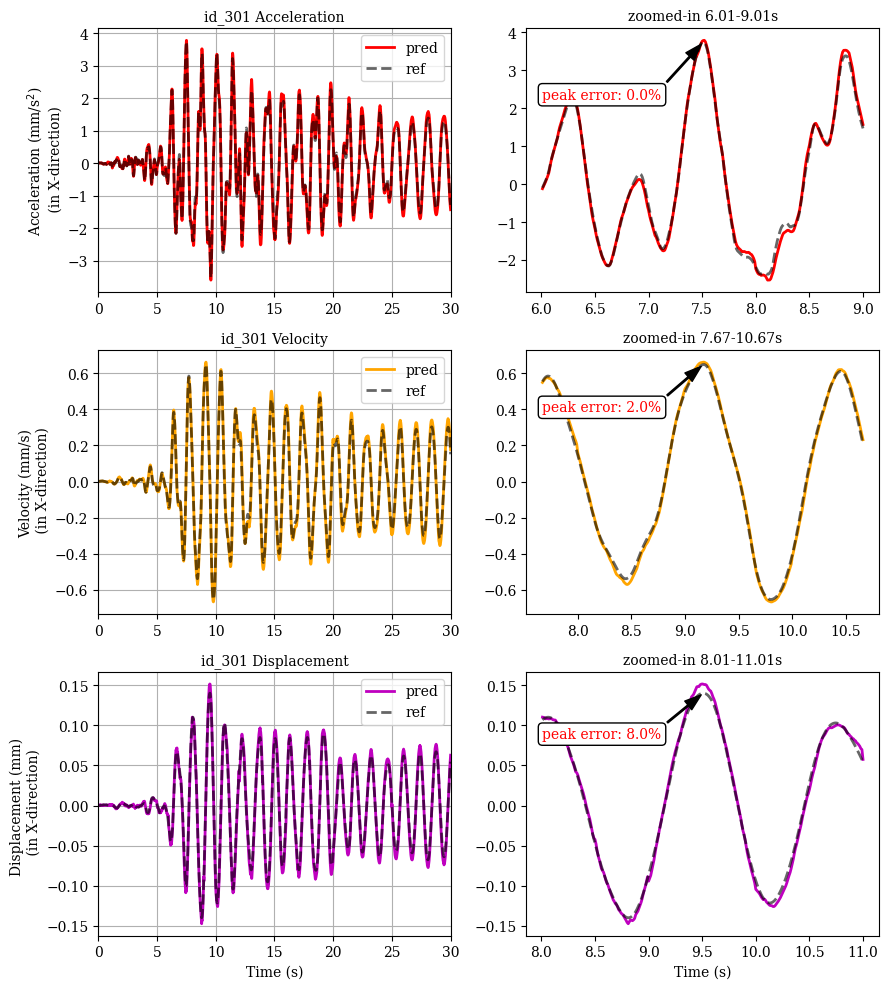

In [ ]:
%%time
ii = np.random.randint(0,len(y_ref), 1)[0]
# ii = 386
print(ii)
fig, axs = plt.subplots(3,2, figsize=(9, 10))
for ia in range(3):
  y_rf = y_ref[ii,:,-6+ia]
  y_predict = y_predict_all[ii,150:,-6+ia]
  plot_results2(axs, y_rf, y_predict, fsize, ia, ii)

plt.tight_layout();
# plt.savefig('sparse1.png', dpi=350)

978
CPU times: user 471 ms, sys: 5.66 ms, total: 477 ms
Wall time: 478 ms


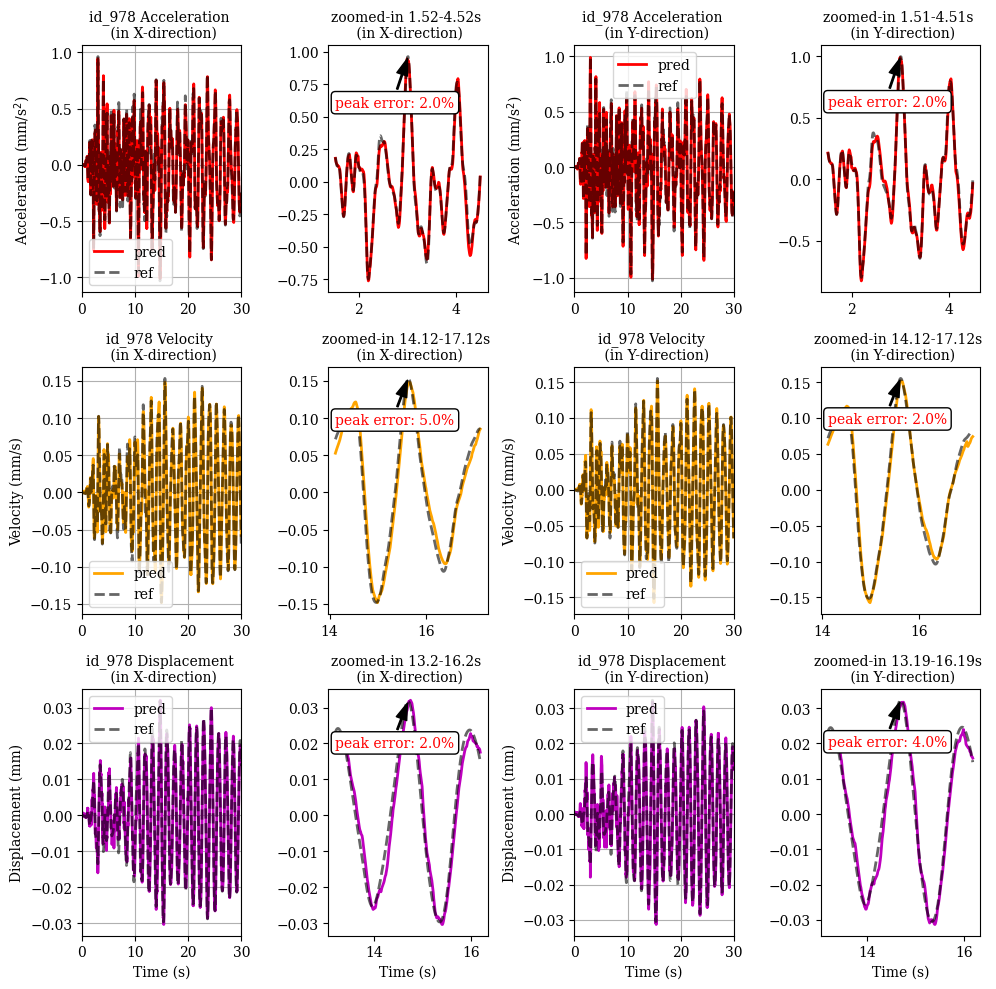

In [ ]:
%%time
ii = np.random.randint(0,len(y_ref), 1)[0]
# ii = 386
print(ii)
fig, axs = plt.subplots(3,4, figsize=(10, 10))
for ia in range(3):
  y_rf = y_ref[ii,:,-6+ia]
  y_predict = y_predict_all[ii,150:,-6+ia]
  plot_results2(axs, y_rf, y_predict, fsize, ia, ii)
  y_rf = y_ref[ii,:,-3+ia]
  y_predict = y_predict_all[ii,150:,-3+ia]
  plot_results3(axs, y_rf, y_predict, fsize, ia, ii)

plt.tight_layout();
# plt.savefig('sparse1.png', dpi=350)

In [ ]:
df = df_new
list(df)

['m1',
 'm2',
 'm3',
 'm4',
 'm5',
 'm6',
 'J1',
 'J2',
 'J3',
 'J4',
 'J5',
 'J6',
 'c1',
 'c2',
 'c3',
 'c4',
 'c5',
 'c6',
 'kx1',
 'kx2',
 'kx3',
 'kx4',
 'kx5',
 'kx6',
 'ky1',
 'ky2',
 'ky3',
 'ky4',
 'ky5',
 'ky6',
 'k_theta1',
 'k_theta2',
 'k_theta3',
 'k_theta4',
 'k_theta5',
 'k_theta6',
 'ex1',
 'ex2',
 'ex3',
 'ex4',
 'ex5',
 'ex6',
 'ey1',
 'ey2',
 'ey3',
 'ey4',
 'ey5',
 'ey6',
 'intensity_x',
 'intensity_y',
 'disp_ground',
 'idEQ',
 'disp_1',
 'disp_7',
 'disp_13',
 'disp_19',
 'disp_25',
 'disp_31',
 'disp_2',
 'disp_8',
 'disp_14',
 'disp_20',
 'disp_26',
 'disp_32',
 'disp_3',
 'disp_9',
 'disp_15',
 'disp_21',
 'disp_27',
 'disp_33',
 'disp_4',
 'disp_10',
 'disp_16',
 'disp_22',
 'disp_28',
 'disp_34',
 'disp_5',
 'disp_11',
 'disp_17',
 'disp_23',
 'disp_29',
 'disp_35',
 'disp_6',
 'disp_12',
 'disp_18',
 'disp_24',
 'disp_30',
 'disp_36',
 'encode_0',
 'encode_1',
 'max_disp']

In [ ]:
list_mm = df[[f'm{i+1}' for i in range(6)]].values
list_cc = df[[f'c{i+1}' for i in range(6)]].values
list_kx = df[[f'kx{i+1}' for i in range(6)]].values


In [ ]:
identity_matrix = np.eye(Nm)
list_mm = df[[f'm{i+1}' for i in range(6)]].values
list_cc = df[[f'c{i+1}' for i in range(6)]].values
list_kx = df[[f'ky{i+1}' for i in range(6)]].values
M_ = np.einsum('bi,ij->bij', list_mm, identity_matrix)
C_ = np.einsum('bi,ij->bij', list_cc, identity_matrix)
K_ = np.einsum('bi,ij->bij', list_kx, identity_matrix)
for i in range(Nm-1):
  K_[:,i,i] += list_kx[:,i+1]
  K_[:,i,i+1] = -list_kx[:,i+1]
  K_[:,i+1,i] = -list_kx[:,i+1]

for i in range(Nm-1):
  C_[:,i,i] += list_cc[:,i+1]
  C_[:,i,i+1] = -list_cc[:,i+1]
  C_[:,i+1,i] = -list_cc[:,i+1]

x_tt = y_ref
mck_ref     = np.einsum('bij,bLj->bLi', M_, x_tt[:,:,:Nm]) + np.einsum('bij,bLj->bLi', C_, x_tt[:,:,Nm:2*Nm])+ np.einsum('bij,bLj->bLi', K_, x_tt[:,:,2*Nm:3*Nm])
mck_ref      += np.einsum('bij,bLj->bLi', M_, x_tt[:,:,3*Nm:4*Nm]) + np.einsum('bij,bLj->bLi', C_, x_tt[:,:,4*Nm:5*Nm])+ np.einsum('bij,bLj->bLi', K_, x_tt[:,:,5*Nm:6*Nm])
x_tt = y_predict_all[:,150:,:]
mck_predict = np.einsum('bij,bLj->bLi', M_, x_tt[:,:,:Nm]) + np.einsum('bij,bLj->bLi', C_, x_tt[:,:,Nm:2*Nm])+ np.einsum('bij,bLj->bLi', K_, x_tt[:,:,2*Nm:3*Nm])
mck_predict += np.einsum('bij,bLj->bLi', M_, x_tt[:,:,3*Nm:4*Nm]) + np.einsum('bij,bLj->bLi', C_, x_tt[:,:,4*Nm:5*Nm])+ np.einsum('bij,bLj->bLi', K_, x_tt[:,:,5*Nm:6*Nm])


In [ ]:
mck_residual = np.zeros_like(mck_ref, dtype=float)
non_zero_mask = np.where(mck_ref > 1E-6)
mck_residual[non_zero_mask] = ((mck_ref[non_zero_mask] - mck_predict[non_zero_mask]) / np.maximum(np.abs(mck_predict[non_zero_mask]),np.abs(mck_ref[non_zero_mask])) * 100)
mck_residual = np.mean(mck_residual, axis=(1,2))

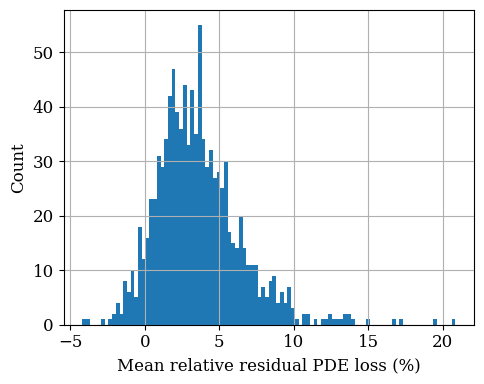

In [ ]:
plt.figure(figsize=(5,4))
plt.hist(mck_residual,bins=100);
plt.ylabel('Count')
plt.xlabel(f'Mean relative residual PDE loss (%)')
plt.grid(True)
plt.tight_layout()

